In [6]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Load CSV into pandas
df = pd.read_csv("Online Retail.csv", encoding="latin1")
df.columns = [c.strip() for c in df.columns]

# Check shape
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (541909, 10)

First 5 rows:


,ï»¿InvoiceNo,InvoiceDate,InvoiceTime,StockCode,Description,Quantity,UnitPrice,Totalsale,CustomerID,Country
0,536365,01-12-2010,08:26:00 AM,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850.0,United Kingdom
1,536365,01-12-2010,08:26:00 AM,71053,WHITE METAL LANTERN,6,3.39,20.34,17850.0,United Kingdom
2,536365,01-12-2010,08:26:00 AM,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,17850.0,United Kingdom
3,536365,01-12-2010,08:26:00 AM,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,17850.0,United Kingdom
4,536365,01-12-2010,08:26:00 AM,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,17850.0,United Kingdom


In [8]:
# Fix column name encoding issue
df.columns = [c.strip().lstrip("\ufeff").lstrip("ï»¿") for c in df.columns]

# Rename first 10 columns only — leave rest as is
df.rename(columns={
    df.columns[0]: 'InvoiceNo',
    'InvoiceDate': 'InvoiceDate',
    'InvoiceTime': 'InvoiceTime',
    'StockCode': 'StockCode',
    'Description': 'Description',
    'Quantity': 'Quantity',
    'UnitPrice': 'UnitPrice',
    'Totalsale': 'TotalSale',
    'CustomerID': 'CustomerID',
    'Country': 'Country'
}, inplace=True)

# Basic cleaning
df['TotalSale'] = pd.to_numeric(df['TotalSale'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce')
df = df.dropna(subset=['TotalSale'])

# Parse datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
df['IsReturn'] = df['Quantity'] < 0

print("Cleaned shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head(2)

Cleaned shape: (541909, 12)

Column names: ['InvoiceNo', 'InvoiceDate', 'InvoiceTime', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'TotalSale', 'CustomerID', 'Country', 'YearMonth', 'IsReturn']


,InvoiceNo,InvoiceDate,InvoiceTime,StockCode,Description,Quantity,UnitPrice,TotalSale,CustomerID,Country,YearMonth,IsReturn
0,536365,2010-12-01,08:26:00 AM,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850.0,United Kingdom,2010-12-01,False
1,536365,2010-12-01,08:26:00 AM,71053,WHITE METAL LANTERN,6,3.39,20.34,17850.0,United Kingdom,2010-12-01,False


In [10]:
# Create SQLite database and load data
conn = sqlite3.connect("retail.db")

# Load dataframe into SQL table
df.to_sql("retail", conn, if_exists="replace", index=False)

print("✅ Data loaded into SQLite database!")
print(f"✅ Table 'retail' created with {len(df):,} rows")

# Test with simple SQL query
test = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM retail", conn)
print(f"\nSQL Test — Total rows: {test['total_rows'][0]:,}")

✅ Data loaded into SQLite database!
✅ Table 'retail' created with 541,909 rows

SQL Test — Total rows: 541,909


In [12]:
# ============================================================
# SQL QUERY 1: KEY KPIs
# ============================================================

kpi_query = """
SELECT 
    ROUND(SUM(CASE WHEN IsReturn = 0 THEN TotalSale ELSE 0 END), 2) AS Total_Revenue,
    COUNT(DISTINCT InvoiceNo)                                         AS Total_Orders,
    COUNT(DISTINCT CustomerID)                                        AS Unique_Customers,
    ROUND(SUM(CASE WHEN IsReturn = 0 THEN TotalSale ELSE 0 END) / 
          COUNT(DISTINCT InvoiceNo), 2)                               AS Avg_Order_Value,
    SUM(CASE WHEN IsReturn = 1 THEN 1 ELSE 0 END)                    AS Return_Transactions,
    ROUND(SUM(CASE WHEN IsReturn = 1 THEN TotalSale ELSE 0 END), 2)  AS Return_Revenue
FROM retail
"""

kpis = pd.read_sql_query(kpi_query, conn)

print("=" * 50)
print("         KEY PERFORMANCE INDICATORS")
print("=" * 50)
print(f"  Total Revenue       : £{kpis['Total_Revenue'][0]:>12,.2f}")
print(f"  Total Orders        : {kpis['Total_Orders'][0]:>12,}")
print(f"  Unique Customers    : {kpis['Unique_Customers'][0]:>12,}")
print(f"  Avg Order Value     : £{kpis['Avg_Order_Value'][0]:>12,.2f}")
print(f"  Return Transactions : {kpis['Return_Transactions'][0]:>12,}")
print(f"  Return Revenue      : £{kpis['Return_Revenue'][0]:>12,.2f}")
print("=" * 50)

         KEY PERFORMANCE INDICATORS
  Total Revenue       : £10,644,560.42
  Total Orders        :       25,900
  Unique Customers    :        4,372
  Avg Order Value     : £      410.99
  Return Transactions :       10,624
  Return Revenue      : £ -896,812.49


Monthly Revenue Data:
    YearMonth  Monthly_Revenue  Monthly_Returns  Monthly_Orders
0  2010-12-01        823746.14        -74789.12            2025
1  2011-01-01        691364.56       -131364.30            1476
2  2011-02-01        523631.89        -25569.24            1393
3  2011-03-01        717639.36        -34372.28            1983
4  2011-04-01        537808.62        -44601.50            1744
5  2011-05-01        770536.02        -47202.51            2162
6  2011-06-01        761739.90        -70616.78            2012
7  2011-07-01        719221.19        -37921.08            1927
8  2011-08-01        737014.26        -54333.75            1737
9  2011-09-01       1058590.17        -38902.55            2327
10 2011-10-01       1154979.30        -84274.63            2637
11 2011-11-01       1509496.33        -47740.08            3462
12 2011-12-01        638792.68       -205124.67            1015


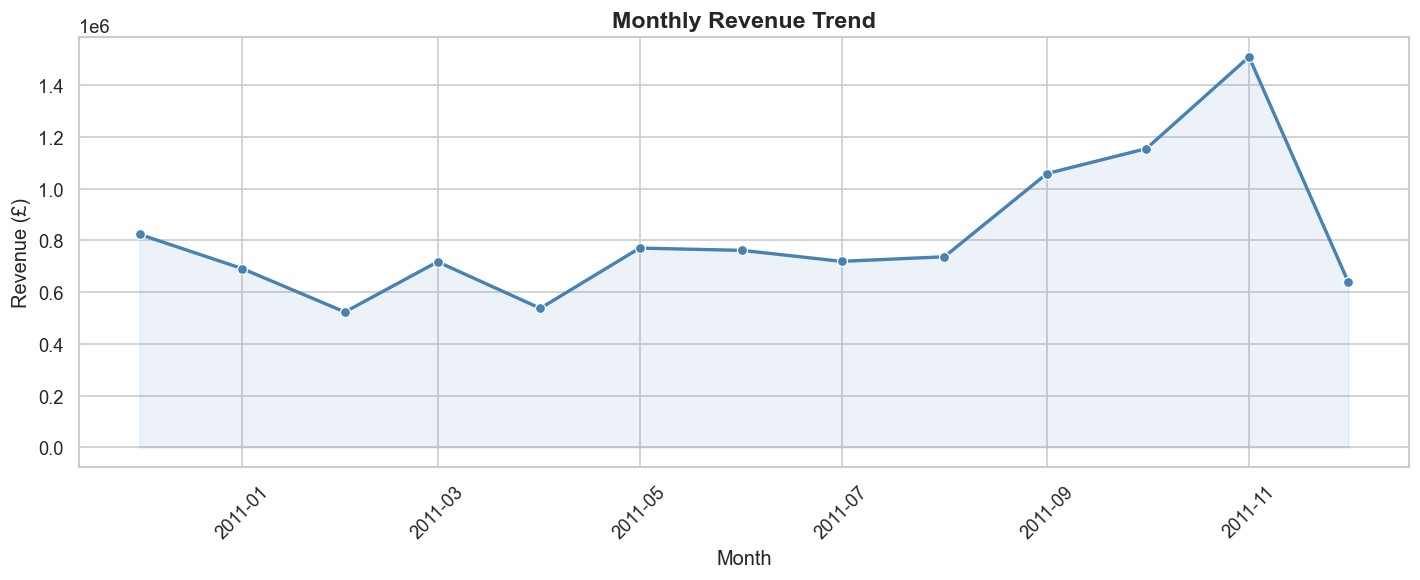

In [14]:
# ============================================================
# SQL QUERY 2: MONTHLY REVENUE TREND
# ============================================================

monthly_query = """
SELECT 
    YearMonth,
    ROUND(SUM(CASE WHEN IsReturn = 0 THEN TotalSale ELSE 0 END), 2) AS Monthly_Revenue,
    ROUND(SUM(CASE WHEN IsReturn = 1 THEN TotalSale ELSE 0 END), 2) AS Monthly_Returns,
    COUNT(DISTINCT InvoiceNo) AS Monthly_Orders
FROM retail
GROUP BY YearMonth
ORDER BY YearMonth
"""

monthly = pd.read_sql_query(monthly_query, conn)
monthly['YearMonth'] = pd.to_datetime(monthly['YearMonth'])

print("Monthly Revenue Data:")
print(monthly)

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='YearMonth', y='Monthly_Revenue',
             marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['YearMonth'], monthly['Monthly_Revenue'],
                 alpha=0.1, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 10 Products:
                          Description  Total_Revenue  Total_Units_Sold  \
0                      DOTCOM POSTAGE      206248.77               708   
1            REGENCY CAKESTAND 3 TIER      174484.74             13890   
2         PAPER CRAFT , LITTLE BIRDIE      168469.60             80995   
3  WHITE HANGING HEART T-LIGHT HOLDER      106292.77             37895   
4                       PARTY BUNTING       99504.33             18299   
5             JUMBO BAG RED RETROSPOT       94340.05             48478   
6      MEDIUM CERAMIC TOP STORAGE JAR       81700.92             78033   
7                              Manual       78112.82              7231   
8                             POSTAGE       78101.88              3150   
9                  RABBIT NIGHT LIGHT       66964.99             30788   

   Number_of_Orders  
0               708  
1              1989  
2                 1  
3              2260  
4              1686  
5              2092  
6             

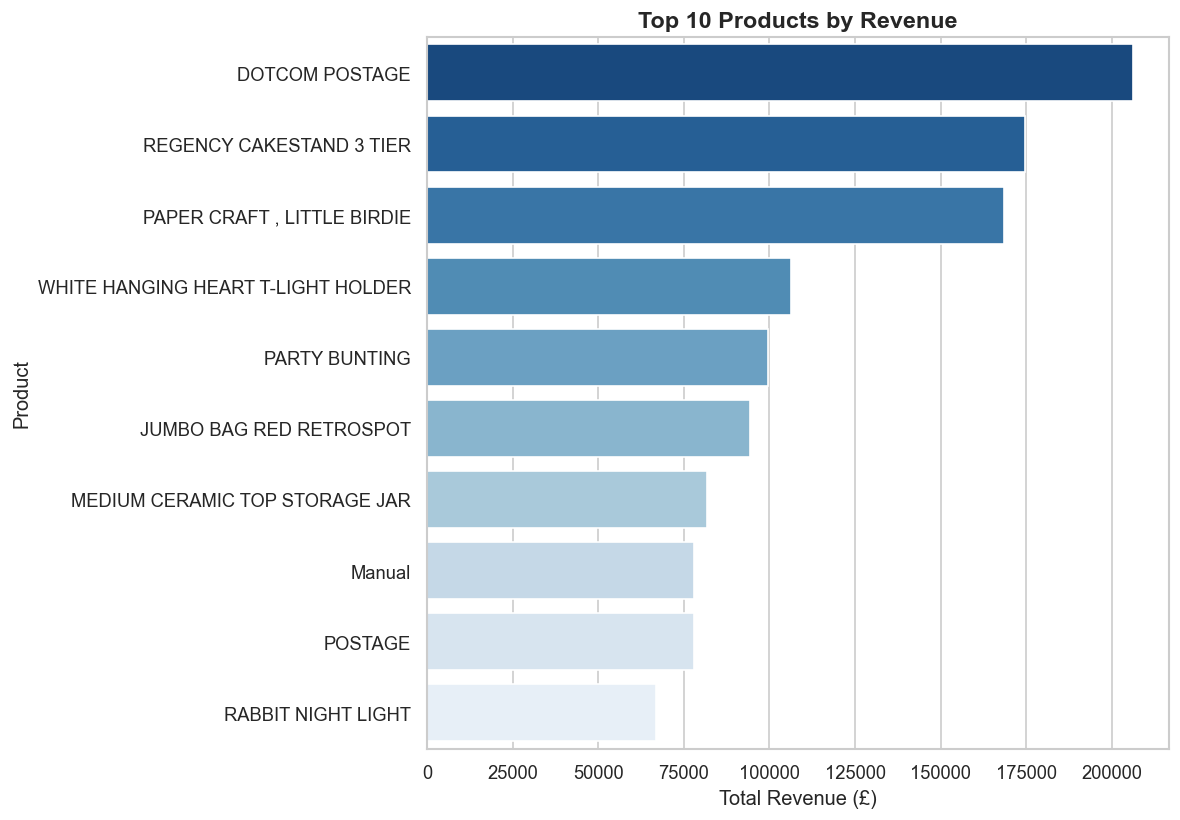

In [16]:
# ============================================================
# SQL QUERY 3: TOP 10 PRODUCTS BY REVENUE
# ============================================================

products_query = """
SELECT 
    Description,
    ROUND(SUM(TotalSale), 2)  AS Total_Revenue,
    SUM(Quantity)              AS Total_Units_Sold,
    COUNT(DISTINCT InvoiceNo)  AS Number_of_Orders
FROM retail
WHERE IsReturn = 0
    AND Description != ''
    AND Description IS NOT NULL
GROUP BY Description
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_products = pd.read_sql_query(products_query, conn)
print("Top 10 Products:")
print(top_products)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=top_products, x='Total_Revenue', y='Description',
            hue='Description', palette='Blues_r', legend=False)
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

Top 10 Products:
                          Description  Total_Revenue  Total_Units_Sold  \
0                      DOTCOM POSTAGE      206248.77               708   
1            REGENCY CAKESTAND 3 TIER      174484.74             13890   
2         PAPER CRAFT , LITTLE BIRDIE      168469.60             80995   
3  WHITE HANGING HEART T-LIGHT HOLDER      106292.77             37895   
4                       PARTY BUNTING       99504.33             18299   
5             JUMBO BAG RED RETROSPOT       94340.05             48478   
6      MEDIUM CERAMIC TOP STORAGE JAR       81700.92             78033   
7                              Manual       78112.82              7231   
8                             POSTAGE       78101.88              3150   
9                  RABBIT NIGHT LIGHT       66964.99             30788   

   Number_of_Orders  
0               708  
1              1989  
2                 1  
3              2260  
4              1686  
5              2092  
6             

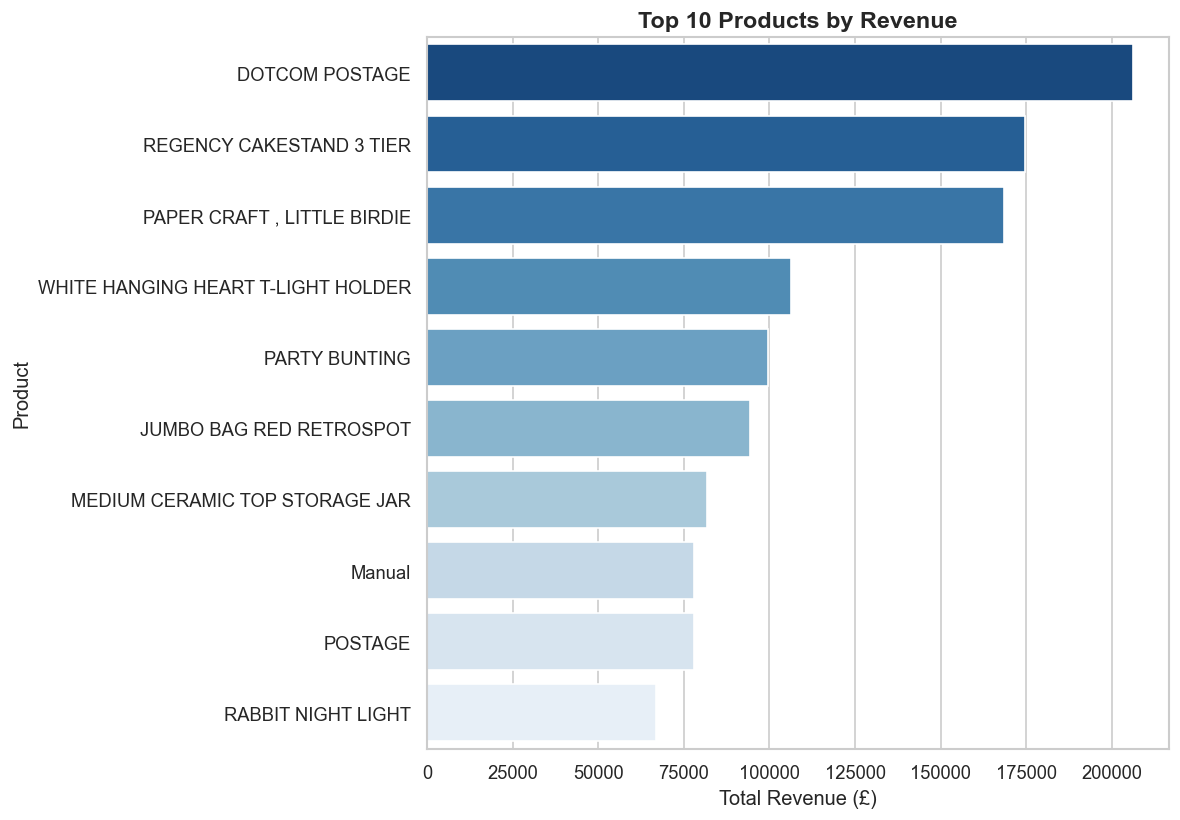

In [18]:
# ============================================================
# SQL QUERY 3: TOP 10 PRODUCTS BY REVENUE
# ============================================================

products_query = """
SELECT 
    Description,
    ROUND(SUM(TotalSale), 2)  AS Total_Revenue,
    SUM(Quantity)              AS Total_Units_Sold,
    COUNT(DISTINCT InvoiceNo)  AS Number_of_Orders
FROM retail
WHERE IsReturn = 0
    AND Description != ''
    AND Description IS NOT NULL
GROUP BY Description
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_products = pd.read_sql_query(products_query, conn)
print("Top 10 Products:")
print(top_products)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=top_products, x='Total_Revenue', y='Description',
            hue='Description', palette='Blues_r', legend=False)
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

Regional Performance:
          Country  Total_Revenue  Total_Orders  Unique_Customers      AOV
0  United Kingdom     9003097.96         18786              3921   479.25
1     Netherlands      285446.34            95                 9  3004.70
2            EIRE      283453.96           288                 3   984.22
3         Germany      228867.14           457                94   500.80
4          France      209715.11           392                87   534.99
5       Australia      138521.31            57                 9  2430.20
6           Spain       61577.11            90                30   684.19
7     Switzerland       57089.90            54                21  1057.22
8         Belgium       41196.34            98                25   420.37
9          Sweden       38378.33            36                 8  1066.06


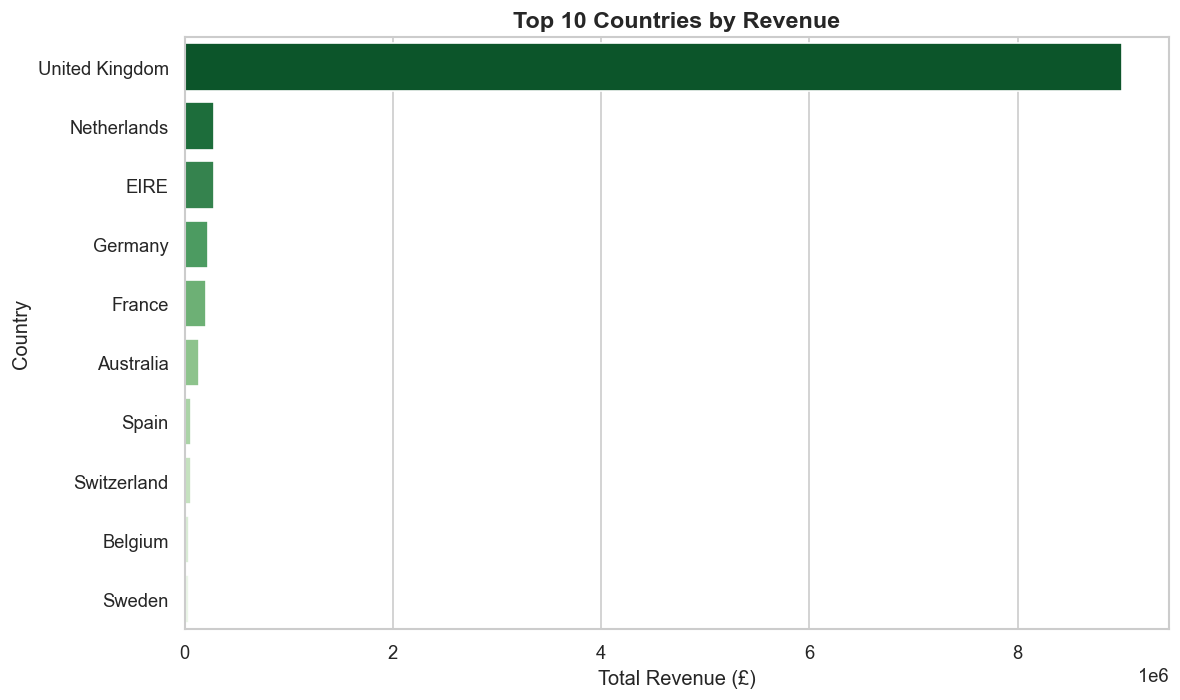

In [20]:
# ============================================================
# SQL QUERY 4: REGIONAL PERFORMANCE (TOP COUNTRIES)
# ============================================================

regional_query = """
SELECT 
    Country,
    ROUND(SUM(TotalSale), 2)   AS Total_Revenue,
    COUNT(DISTINCT InvoiceNo)   AS Total_Orders,
    COUNT(DISTINCT CustomerID)  AS Unique_Customers,
    ROUND(SUM(TotalSale) / COUNT(DISTINCT InvoiceNo), 2) AS AOV
FROM retail
WHERE IsReturn = 0
    AND Country != 'Unspecified'
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 10
"""

regional = pd.read_sql_query(regional_query, conn)
print("Regional Performance:")
print(regional)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=regional, x='Total_Revenue', y='Country',
            hue='Country', palette='Greens_r', legend=False)
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

Customer Segments:
      Segment  Count
0   Low Value   1447
1   Mid Value   1446
2  High Value   1446

Top 5 Customers by Revenue:
   CustomerID  Total_Spent  Total_Orders       AOV     Segment
0     14646.0    280206.02            74   3786.57  High Value
1     18102.0    259657.30            60   4327.62  High Value
2     17450.0    194550.79            46   4229.37  High Value
3     16446.0    168472.50             2  84236.25  High Value
4     14911.0    143825.06           201    715.55  High Value


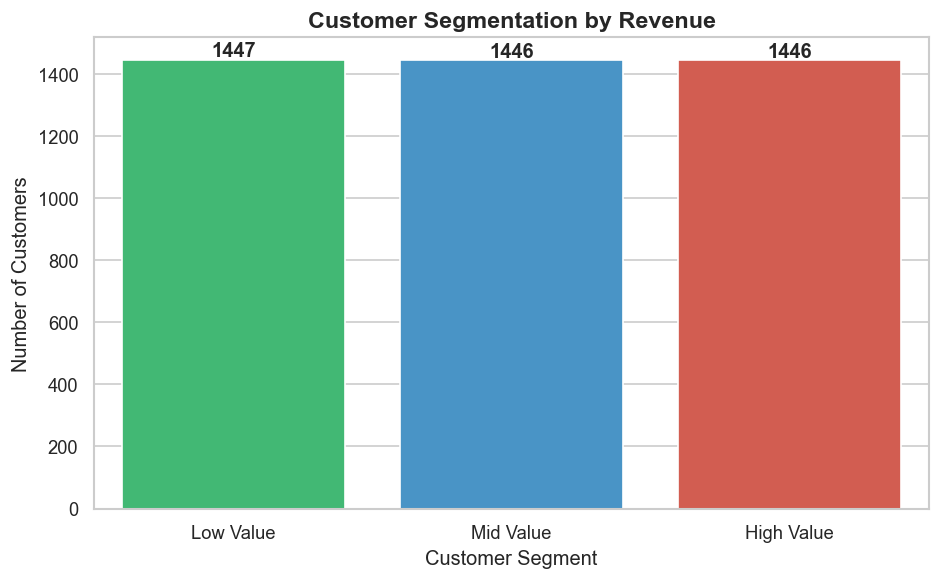

In [22]:
# ============================================================
# SQL QUERY 5: CUSTOMER SEGMENTATION (RFM)
# ============================================================

customer_query = """
SELECT 
    CustomerID,
    ROUND(SUM(TotalSale), 2)      AS Total_Spent,
    COUNT(DISTINCT InvoiceNo)      AS Total_Orders,
    ROUND(SUM(TotalSale) / 
          COUNT(DISTINCT InvoiceNo), 2) AS AOV
FROM retail
WHERE IsReturn = 0
    AND CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY Total_Spent DESC
"""

customers = pd.read_sql_query(customer_query, conn)

# Segment customers into 3 tiers
customers['Segment'] = pd.qcut(
    customers['Total_Spent'],
    q=3,
    labels=['Low Value', 'Mid Value', 'High Value']
)

seg_counts = customers['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']

print("Customer Segments:")
print(seg_counts)
print(f"\nTop 5 Customers by Revenue:")
print(customers.head())

# Plot
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c']
sns.barplot(data=seg_counts, x='Segment', y='Count',
            hue='Segment', palette=colors, legend=False)
plt.title('Customer Segmentation by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
for i, row in seg_counts.iterrows():
    plt.text(i, row['Count'] + 10, str(row['Count']), 
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Total Orders: 18,532
Average Order Value: £480.87
Median Order Value:  £303.04
Max Order Value:     £168,469.60


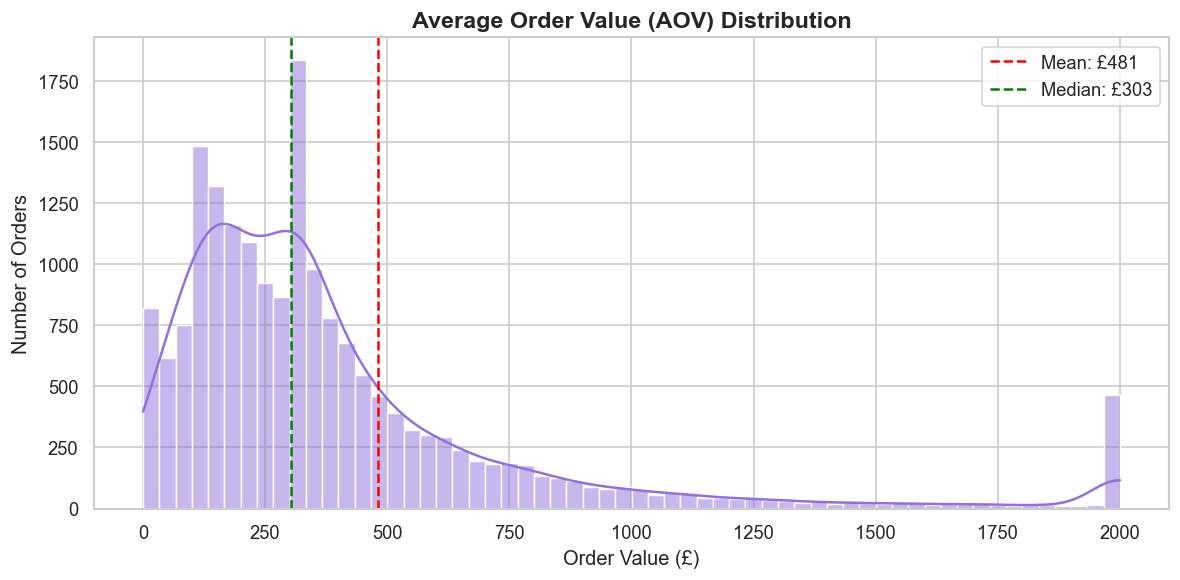

In [24]:
# ============================================================
# SQL QUERY 6: AOV DISTRIBUTION
# ============================================================

aov_query = """
SELECT 
    InvoiceNo,
    ROUND(SUM(TotalSale), 2) AS Order_Value
FROM retail
WHERE IsReturn = 0
    AND CustomerID IS NOT NULL
GROUP BY InvoiceNo
HAVING Order_Value > 0
ORDER BY Order_Value DESC
"""

aov_df = pd.read_sql_query(aov_query, conn)

print(f"Total Orders: {len(aov_df):,}")
print(f"Average Order Value: £{aov_df['Order_Value'].mean():,.2f}")
print(f"Median Order Value:  £{aov_df['Order_Value'].median():,.2f}")
print(f"Max Order Value:     £{aov_df['Order_Value'].max():,.2f}")

# Plot — clip at 2000 to remove extreme outliers for better visualization
plt.figure(figsize=(10, 5))
sns.histplot(aov_df['Order_Value'].clip(upper=2000), 
             bins=60, kde=True, color='mediumpurple')
plt.title('Average Order Value (AOV) Distribution', 
          fontsize=14, fontweight='bold')
plt.xlabel('Order Value (£)')
plt.ylabel('Number of Orders')
plt.axvline(aov_df['Order_Value'].mean(), color='red', 
            linestyle='--', label=f"Mean: £{aov_df['Order_Value'].mean():,.0f}")
plt.axvline(aov_df['Order_Value'].median(), color='green', 
            linestyle='--', label=f"Median: £{aov_df['Order_Value'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

Return Rate by Country:
     Country  Normal_Orders  Return_Orders  Return_Rate_Pct  Return_Revenue
0        USA            179            112            38.49        -1849.47
1      Malta            112             15            11.81         -220.12
2      Japan            321             37            10.34        -2075.75
3  Australia           1185             74             5.88        -1444.04
4      Italy            758             45             5.60         -592.73
5    Germany           9042            453             4.77        -7168.93
6       EIRE           7894            302             3.68       -20177.14
7     Poland            330             11             3.23         -121.51
8  Singapore            222              7             3.06       -12158.90
9     Sweden            451             11             2.38        -1782.42


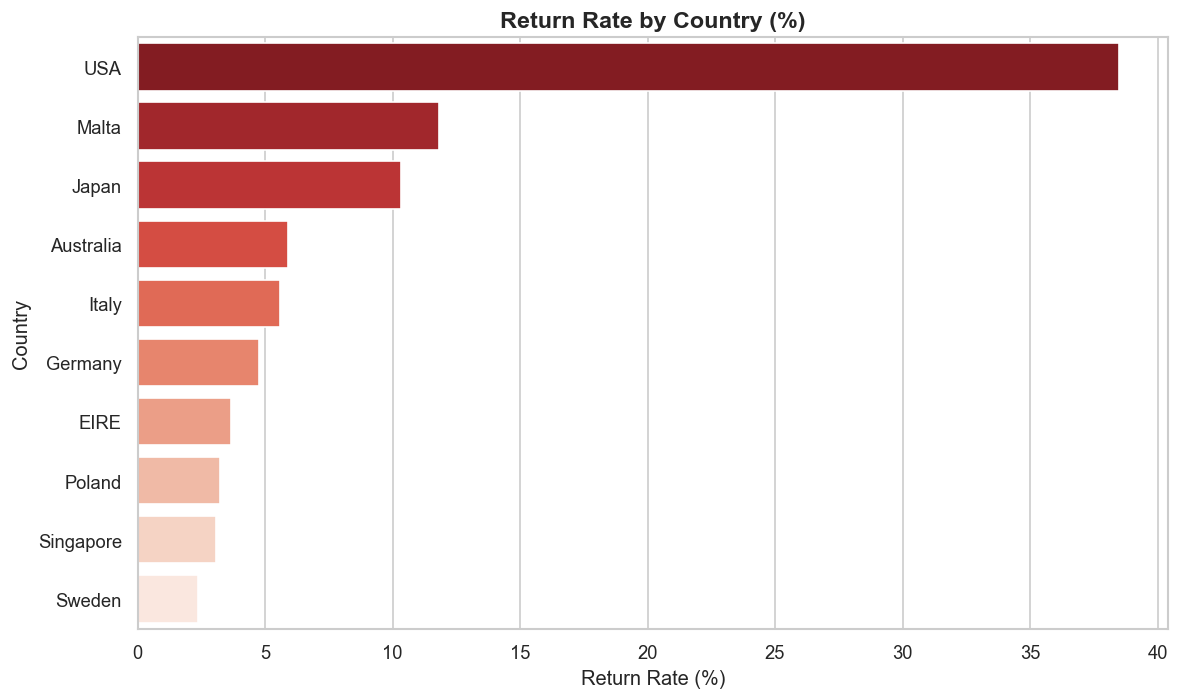

In [25]:
# ============================================================
# SQL QUERY 7: RETURN RATE BY COUNTRY
# ============================================================

returns_query = """
SELECT 
    Country,
    COUNT(CASE WHEN IsReturn = 0 THEN 1 END)  AS Normal_Orders,
    COUNT(CASE WHEN IsReturn = 1 THEN 1 END)  AS Return_Orders,
    ROUND(COUNT(CASE WHEN IsReturn = 1 THEN 1 END) * 100.0 / 
          COUNT(*), 2)                         AS Return_Rate_Pct,
    ROUND(SUM(CASE WHEN IsReturn = 1 
              THEN TotalSale ELSE 0 END), 2)   AS Return_Revenue
FROM retail
GROUP BY Country
HAVING Normal_Orders > 100
ORDER BY Return_Rate_Pct DESC
LIMIT 10
"""

returns = pd.read_sql_query(returns_query, conn)
print("Return Rate by Country:")
print(returns)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=returns, x='Return_Rate_Pct', y='Country',
            hue='Country', palette='Reds_r', legend=False)
plt.title('Return Rate by Country (%)', fontsize=14, fontweight='bold')
plt.xlabel('Return Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [26]:
# Save sample dataset for GitHub
sample = df.sample(50000, random_state=42)
sample.to_csv("Online_Retail_Sample.csv", index=False)

import os
size = os.path.getsize("Online_Retail_Sample.csv") / (1024*1024)
print(f"✅ Sample saved! File size: {size:.2f} MB")
print(f"✅ Rows: {len(sample):,}")

✅ Sample saved! File size: 5.47 MB
✅ Rows: 50,000
